In [1]:
from pathlib import Path
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
DATASET_DIR = Path("../data/esad")

print(DATASET_DIR.exists())

True


In [3]:
with open(DATASET_DIR / "obj.names", "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

print(f"Number of classes: {len(class_names)}")

for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 21
0 -> CuttingMesocolon
1 -> PullingVasDeferens
2 -> ClippingVasDeferens
3 -> CuttingVasDeferens
4 -> ClippingTissue
5 -> PullingSeminalVesicle
6 -> ClippingSeminalVesicle
7 -> CuttingSeminalVesicle
8 -> SuckingBlood
9 -> SuckingSmoke
10 -> PullingTissue
11 -> CuttingTissue
12 -> BaggingProstate
13 -> BladderNeckDissection
14 -> BladderAnastomosis
15 -> PullingProstate
16 -> ClippingBladderNeck
17 -> CuttingThread
18 -> UrethraDissection
19 -> CuttingProstate
20 -> PullingBladderNeck


In [4]:
image_files = list(DATASET_DIR.rglob("*.jpg"))

print("Total images:", len(image_files))

Total images: 40152


In [5]:
empty_labels = 0
non_empty_labels = 0

for img_path in image_files:

    txt_path = img_path.with_suffix(".txt")

    if not txt_path.exists():
        continue

    if txt_path.stat().st_size == 0:
        empty_labels += 1
    else:
        non_empty_labels += 1

print("Empty label files:", empty_labels)
print("Non-empty label files:", non_empty_labels)

Empty label files: 21359
Non-empty label files: 18793


In [6]:
def load_yolo_labels(txt_path):

    boxes = []

    if txt_path.stat().st_size == 0:
        return boxes

    with open(txt_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            class_id = int(parts[0])

            cx = float(parts[1])
            cy = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

            boxes.append(
                {
                    "class_id": class_id,
                    "cx": cx,
                    "cy": cy,
                    "w": w,
                    "h": h
                }
            )

    return boxes

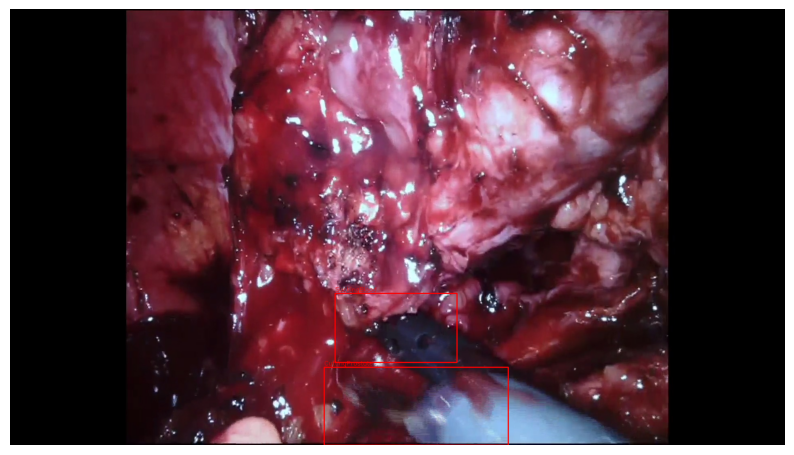

In [7]:
annotated_images = []

for img_path in image_files:

    txt_path = img_path.with_suffix(".txt")

    if txt_path.exists() and txt_path.stat().st_size > 0:
        annotated_images.append(img_path)

sample_img = random.choice(annotated_images)

sample_txt = sample_img.with_suffix(".txt")

labels = load_yolo_labels(sample_txt)

image = cv2.imread(str(sample_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h_img, w_img = image.shape[:2]

for label in labels:

    cx = label["cx"] * w_img
    cy = label["cy"] * h_img

    bw = label["w"] * w_img
    bh = label["h"] * h_img

    x1 = int(cx - bw / 2)
    y1 = int(cy - bh / 2)

    x2 = int(cx + bw / 2)
    y2 = int(cy + bh / 2)

    class_name = class_names[label["class_id"]]

    cv2.rectangle(image,
                  (x1, y1),
                  (x2, y2),
                  (255, 0, 0),
                  2)

    cv2.putText(image,
                class_name,
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
class_counter = Counter()

for img_path in image_files:

    txt_path = img_path.with_suffix(".txt")

    if not txt_path.exists():
        continue

    labels = load_yolo_labels(txt_path)

    for label in labels:

        class_counter[
            class_names[label["class_id"]]
        ] += 1

stats_df = pd.DataFrame(
    class_counter.items(),
    columns=["Class", "Count"]
)

stats_df = stats_df.sort_values(
    by="Count",
    ascending=False
)

stats_df.head(20)

,Class,Count
0,PullingTissue,4877
5,SuckingBlood,3753
1,CuttingTissue,3715
17,BladderAnastomosis,3585
2,PullingSeminalVesicle,2712
19,CuttingSeminalVesicle,2509
15,CuttingProstate,1845
10,BladderNeckDissection,1621
12,PullingProstate,958
4,PullingVasDeferens,457


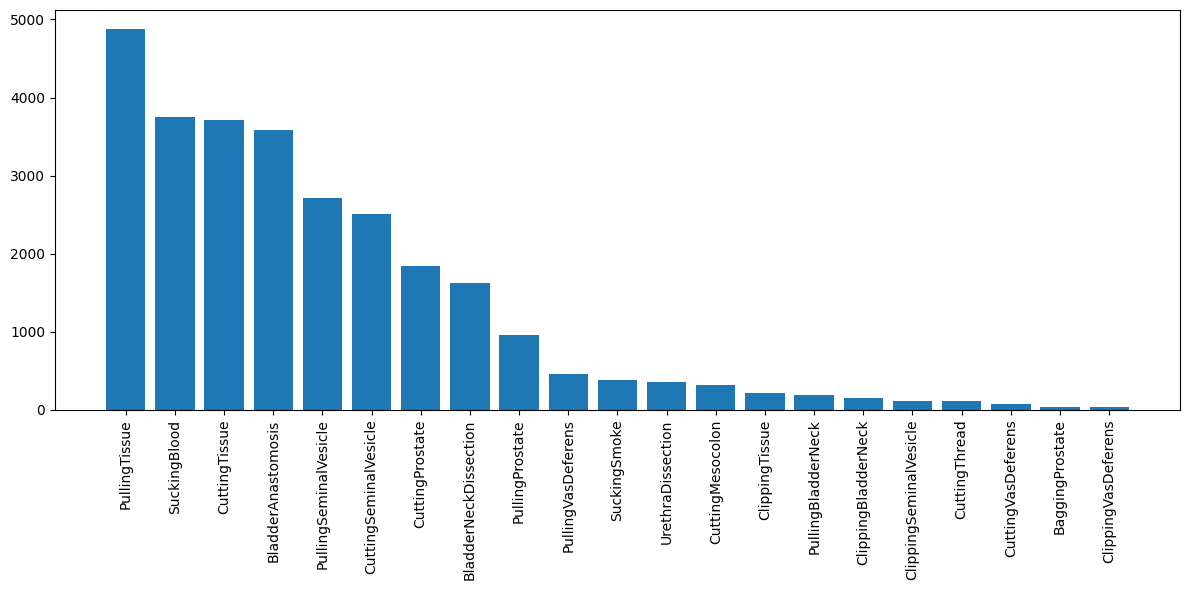

In [9]:
plt.figure(figsize=(12,6))

plt.bar(
    stats_df["Class"],
    stats_df["Count"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [10]:
areas = []

for img_path in image_files:

    txt_path = img_path.with_suffix(".txt")

    if not txt_path.exists():
        continue

    labels = load_yolo_labels(txt_path)

    for label in labels:

        area = label["w"] * label["h"]

        areas.append(area)

print("Min area:", min(areas))
print("Max area:", max(areas))
print("Mean area:", np.mean(areas))

Min area: 0.00520347473
Max area: 0.645431839892
Mean area: 0.17058956173090287
